# 04 — Retrieval-Augmented Support Agent (Phases 6–8)

**Phases 6–8 of 9** for the Hiver SDE-intern take-home. Phase 5 built the historical retrieval memory (RAG recall memory). This notebook closes the agent loop end-to-end:

1. **Phase 6 — drafting** (`src/agent/`): intent classifier + dense retrieval    (message-only, temporal filter) + deterministic *grounded* reply drafting    (never fabricates order numbers / links / amounts).
2. **Phase 7 — escalation** (`src/agent/escalation.py`): a deterministic confidence-based    policy, calibrated on the **dev** set only (golden stays pristine) and frozen thereafter.
3. **Phase 8 — final evaluation on the golden benchmark** (used ONLY here): the intent-classifier    learning curve (majority 0 → dev-140 human → weak-201k proxy labels; LLM-labelled data is    future work), escalation behavior + sensitivity to the confidence floor, grounded-drafting    quality, and an optional LLM judge (disabled when no provider key is set).
4. **Phase 9 — failure analysis** (reports/agent_error_analysis.*) categorizes every golden row.

Golden-benchmark hygiene: the golden/holdout conversations were excluded from the retrieval index (hard assertion), the intent models never see golden rows, the escalation floor is calibrated on dev only, and every agent run applies the temporal filter (retrieved resolutions must predate the customer's message).

## 1. Agent intent models (offline, deterministic)

In [1]:
import json, csv, sys
from pathlib import Path
sys.path.insert(0, '..')

im = json.loads(Path('../reports/agent_intent_models.json').read_text())
for name, m in im.items():
    print('[{}] source={} n_train={} classes_n={}'.format(
        name, m.get('source'), m.get('n_train'), m.get('classes_n')))
    if 'class_counts' in m:
        top = sorted(m['class_counts'].items(), key=lambda x: -x[1])[:4]
        print('    top weak classes:', ', '.join('{}={:,}'.format(k, v) for k, v in top))
print('\nweak-model sanity on dev/validation (proxy labels, human gold):')
print('  dev-140 validation macro-F1:', im['dev']['validation_macro_f1'])
print('  weak-201k on same dev/validation:', im['weak'].get('dev_validation_proxy_macro_f1'))


[weak] source=weak-201k n_train=201741 classes_n=12
    top weak classes: delivery_delay=174,605, service_complaint_escalation=19,801, delivered_but_not_received=2,596, product_return_and_replacement=1,967
[dev] source=dev-140 n_train=140 classes_n=14

weak-model sanity on dev/validation (proxy labels, human gold):
  dev-140 validation macro-F1: 0.069
  weak-201k on same dev/validation: 0.3092


## 2. Final evaluation on the golden benchmark (200 rows)

**Learning curve.** Three models, same golden targets. Note the label-space mismatch: the weak-201k model has 12 proxy classes (no `none`), dev-140 has 14 human classes — so each model is also scored on the subset of golden rows whose true intent is inside its label space.

In [2]:
ag = json.loads(Path('../reports/agent_results.json').read_text())
print('{:<16} {:>7} {:>8} {:>8}  (golden acc / macro-F1)'.format('model', 'n_train', 'acc', 'F1'))
for pt in ag['intent_learning_curve']:
    print('{:<16} {:>7} {:>8.3f} {:>8.3f}'.format(
        pt['label'], pt['n_train'], pt['accuracy'], pt['macro_f1']))
print('\nOn label-space shared subsets only:')
for pt in ag['intent_learning_curve']:
    s = pt.get('on_shared_subset')
    if s:
        print('  {:<16} n={:>3} acc={:.3f} F1={:.3f}'.format(
            pt['label'], s['n'], s['accuracy'], s['macro_f1']))
print('\nDrafting (deterministic, grounded):')
d = ag['drafting']
print('  auto rows reuse retrieved resolution words: {:>5.1f}%'.format(100*d['resolution_reuse_rate_auto']))
print('  avg cue overlap with golden human reply (url/email/apology/ask/contact): {:.2f}'.format(d['avg_cue_overlap']))
print('  empty drafts:', d['empty_drafts'], '| avg chars:', d['avg_draft_chars'])
print('\nLLM judge:', ag['llm_judge'])


model            n_train      acc       F1  (golden acc / macro-F1)
majority               0    0.160    0.020
dev-140 (human)      140    0.315    0.078
weak-201k         201741    0.245    0.050

On label-space shared subsets only:
  majority         n=200 acc=0.315 F1=0.078
  dev-140 (human)  n=200 acc=0.315 F1=0.078
  weak-201k        n=167 acc=0.293 F1=0.063

Drafting (deterministic, grounded):
  auto rows reuse retrieved resolution words:  95.7%
  avg cue overlap with golden human reply (url/email/apology/ask/contact): 0.29
  empty drafts: 0 | avg chars: 260.3

LLM judge: {'status': 'disabled', 'note': 'no LLM provider key set'}


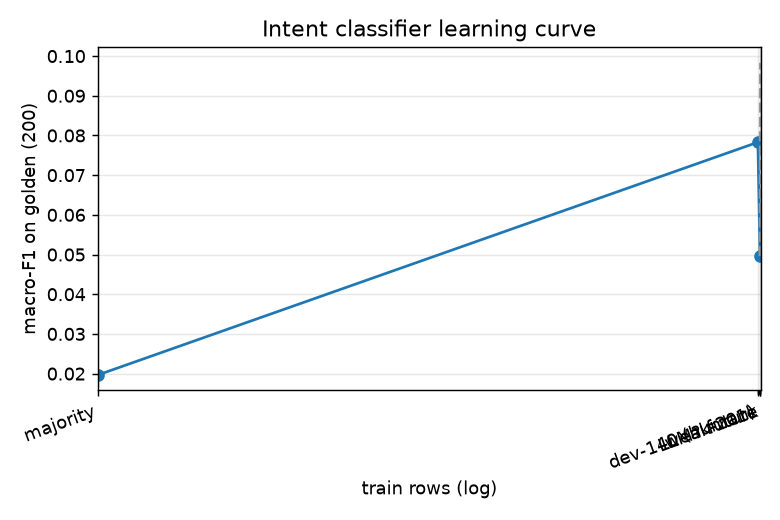

In [3]:
from IPython.display import Image
Image(filename='../reports/figures/agent_learning_curve.png')


## 3. Escalation policy (Phase 7, dev-calibrated floor)

Escalation fires on catch-all intents (`none`/`other_unclear`, no usable reply in top-3, or combined confidence below a **dev-calibrated** floor (`comb_low`, frozen at 0.8775). The same policy is run over the golden rows without any retuning; the table below adds a *sensitivity* analysis across floors to show how the policy's surface responds.

In [4]:
esc = ag['escalation']
print('escalation on golden:', esc['escalate'], '/', ag['n_golden'],
      '({:.1f}%)'.format(100*esc['escalation_rate']))
print('active comb_low floor:', esc['active_comb_low'])
print('escalates by true intent:', esc['by_true_intent'])
print('\nSensitivity: escalate count when the combined-confidence floor moves')
for k, v in esc['sensitivity_to_comb_low'].items():
    print('  comb_low={:>5}: escalate={:>3} ({:.1f}%)'.format(k, v['escalate'], 100*v['rate']))


escalation on golden: 61 / 200 (30.5%)
active comb_low floor: 0.8775
escalates by true intent: {'account_access': 1, 'cancellation': 2, 'charge_issue': 6, 'delivered_but_not_received': 2, 'delivered_wrong_location': 1, 'delivery_delay': 8, 'device_app_issue': 2, 'none': 10, 'order_status_query': 5, 'product_return_and_replacement': 11, 'refund_request': 1, 'service_complaint_escalation': 12}

Sensitivity: escalate count when the combined-confidence floor moves
  comb_low= 0.45: escalate=  2 (1.0%)
  comb_low=  0.6: escalate=  4 (2.0%)
  comb_low= 0.75: escalate= 14 (7.0%)
  comb_low=0.8775: escalate= 62 (31.0%)
  comb_low= 0.95: escalate=189 (94.5%)


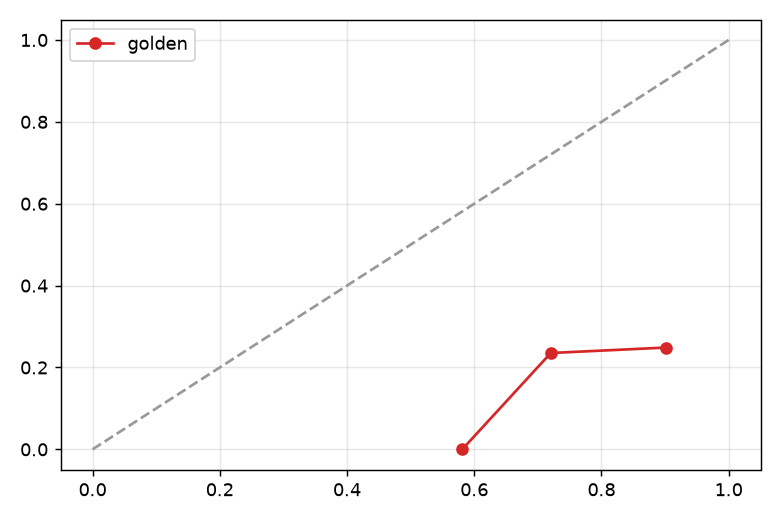

In [5]:
Image(filename='../reports/figures/agent_escalation_calibration.png')


## 4. Error analysis (Phase 9, per-golden-row taxonomy)

In [6]:
ea = json.loads(Path('../reports/agent_error_analysis.json').read_text())
print('golden rows:', ea['n_golden'], '| failure rows:', ea['n_failure_rows'],
      '| success rows:', ea['n_success_rows'])
print('\ncategory counts:')
for k, v in ea['category_counts'].items():
    print('  {:<28}'.format(k), v)
print('\nmost common code combinations:')
for k, v in list(ea['co_occurrence'].items())[:5]:
    print('  {:<46}'.format(k), v)


golden rows: 200 | failure rows: 162 | success rows: 38

category counts:
  intent_off_target            143
  escalation_conservative      61
  intent_close_secondary       8
  drafting_ungrounded          6
  retrieval_lang_mismatch      3

most common code combinations:
  ('intent_off_target',)                         87
  ('escalation_conservative', 'intent_off_target') 47
  ('escalation_conservative',)                   11
  ('intent_close_secondary',)                    6
  ('drafting_ungrounded', 'intent_off_target')   6


## 5. Sample drafts (deterministic, grounded)

In [7]:
rows = json.loads(Path('../reports/agent_rows.json').read_text())
if not rows:
    print('reports/agent_rows.json missing — run:')
    print('  python scripts/evaluate_agent.py --dump-rows reports/agent_rows.json')
else:
    auto = [r for r in rows if r['action'] == 'auto_handle'][:3]
    esc_rows = [r for r in rows if r['action'] == 'escalate'][:2]
    for r in auto:
        print('--- AUTO {} [{} -> {}] conf={}'.format(
            r['example_id'], r['true_intent'], r['intent'], r['action_confidence']))
        print(r['draft'][:260])
        print()
    for r in esc_rows:
        print('--- ESCALATE {} [{} -> {}] {}'.format(
            r['example_id'], r['true_intent'], r['intent'], r['action_reasons'][:1]))
        print(r['draft'][:200])
        print()


--- AUTO challenge-102915 [service_complaint_escalation -> delivery_delay] conf=0.9245
Hello! This is Amazon Customer Service. Hi, Frank! Thanks for reaching out to us! To find out more about Kindle Unlimited and to sign up please visit us here: To help, please share a little more detail (for example the order number or the exact message you see

--- AUTO challenge-1033752 [none -> delivery_delay] conf=0.8801
Hello! This is Amazon Customer Service. Freut mich sehr zu hören, dass meine Kollegen dir helfen konnten. Hab noch einen schönen Tag! To help, please share a little more detail (for example the order number or the exact message you see) and we'll take it from 

--- AUTO challenge-1130527 [order_status_query -> delivery_delay] conf=0.8833
Hello! This is Amazon Customer Service. ¿Has intentado contactar al transportista? Recuerda no compartir informaciones personales por este medio To help, please share a little more detail (for example the order number or the exact message you see)

## 6. Reproduce (deterministic, no API key)

In [8]:
print('''
python scripts/train_agent_intent.py        # weak-201k + dev-140 models
python scripts/calibrate_escalation.py      # dev-only confidence floor
python scripts/evaluate_agent.py --dump-rows reports/agent_rows.json
python scripts/analyze_agent_errors.py reports/agent_rows.json
''')



python scripts/train_agent_intent.py        # weak-201k + dev-140 models
python scripts/calibrate_escalation.py      # dev-only confidence floor
python scripts/evaluate_agent.py --dump-rows reports/agent_rows.json
python scripts/analyze_agent_errors.py reports/agent_rows.json

